<span style = "font-family: Verdana; font-size: 20px">

#### **Visualization**
</span>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as mtick
from sklearn.manifold import TSNE
from PIL import Image
import openchord as ocd
from os import listdir

import unicodedata

In [34]:
data = pd.read_csv('data/modified/viz_pokemon.csv', keep_default_na=False, dtype = {'ID': str})

In [35]:
data.shape[1]

54

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  800 non-null    object 
 1   Name                800 non-null    object 
 2   Type1               800 non-null    object 
 3   Type2               800 non-null    object 
 4   HiddenAbility       800 non-null    object 
 5   Generation          800 non-null    int64  
 6   Hp                  800 non-null    float64
 7   Attack              800 non-null    float64
 8   Defense             800 non-null    float64
 9   SpecialAttack       800 non-null    float64
 10  SpecialDefense      800 non-null    float64
 11  Speed               800 non-null    float64
 12  TotalStats          800 non-null    float64
 13  Weight              800 non-null    float64
 14  Height              800 non-null    float64
 15  GenderProbM         800 non-null    float64
 16  Category

In [37]:
pd.options.display.max_columns = None
data

,ID,Name,Type1,Type2,HiddenAbility,Generation,Hp,Attack,Defense,SpecialAttack,SpecialDefense,Speed,TotalStats,Weight,Height,GenderProbM,Category,CatchRate,EggCycles,LevelingRate,BaseFriendship,IsLegendary,IsMythical,HasMega,EvoStage,TotalEvoStages,PreevoName,DamageFromNormal,DamageFromFighting,DamageFromFlying,DamageFromPoison,DamageFromGround,DamageFromRock,DamageFromBug,DamageFromGhost,DamageFromSteel,DamageFromFire,DamageFromWater,DamageFromGrass,DamageFromElectric,DamageFromPsychic,DamageFromIce,DamageFromDragon,DamageFromDark,DamageFromFairy,Ability1,Ability2,NoGender,EggGroup1,EggGroup2,IsMega,FightsWon,TotalFights,WinPercentage
0,1,Bulbasaur,Grass,Poison,Chlorophyll,1,45.0,49.0,49.0,65.0,65.0,45.0,318.0,6.9,0.7,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,0,1,3,No Preevolution,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,2.00,0.5,0.25,0.5,2.0,2.00,1.0,1.0,0.5,Overgrow,None,0,Monster,Grass,0,37,133,0.278195
1,2,Ivysaur,Grass,Poison,Chlorophyll,1,60.0,62.0,63.0,80.0,80.0,60.0,405.0,13.0,1.0,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,0,2,3,Bulbasaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,2.00,0.5,0.25,0.5,2.0,2.00,1.0,1.0,0.5,Overgrow,None,0,Monster,Grass,0,46,121,0.380165
2,3,Venusaur,Grass,Poison,Chlorophyll,1,80.0,82.0,83.0,100.0,100.0,80.0,525.0,100.0,2.0,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,1,3,3,Ivysaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,2.00,0.5,0.25,0.5,2.0,2.00,1.0,1.0,0.5,Overgrow,None,0,Monster,Grass,0,89,132,0.674242
3,4,Mega Venusaur,Grass,Poison,None,1,80.0,100.0,123.0,122.0,120.0,80.0,625.0,155.5,2.4,0.875,Seed Pokémon,45,20,Medium Slow,70,0,0,1,3,3,Venusaur,1.0,0.5,2.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,0.5,0.25,0.5,2.0,1.00,1.0,1.0,0.5,Thick Fat,None,0,Monster,Grass,1,70,125,0.560000
4,5,Charmander,Fire,Fire,Solar Power,1,39.0,52.0,43.0,60.0,50.0,65.0,309.0,8.5,0.6,0.875,Lizard Pokémon,45,20,Medium Slow,70,0,0,0,1,3,No Preevolution,1.0,1.0,1.0,1.0,2.0,2.0,0.5,1.0,0.50,0.50,2.0,0.50,1.0,1.0,0.50,1.0,1.0,0.5,Blaze,None,0,Monster,Dragon,0,55,112,0.491071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Diancie,Rock,Fairy,None,6,50.0,100.0,150.0,100.0,150.0,50.0,600.0,8.8,0.7,0.500,Jewel Pokémon,3,25,Slow,70,0,1,1,1,1,No Preevolution,0.5,1.0,0.5,1.0,2.0,1.0,0.5,1.0,4.00,0.50,2.0,2.00,1.0,1.0,1.00,0.0,0.5,1.0,Clear Body,None,1,No Eggs Discovered,No Eggs Discovered,0,39,105,0.371429
796,797,Mega Diancie,Rock,Fairy,None,6,50.0,160.0,110.0,160.0,110.0,110.0,700.0,27.8,1.1,0.500,Jewel Pokémon,3,25,Slow,0,0,1,1,1,1,Diancie,0.5,1.0,0.5,1.0,2.0,1.0,0.5,1.0,4.00,0.50,2.0,2.00,1.0,1.0,1.00,0.0,0.5,1.0,Magic Bounce,None,1,No Eggs Discovered,No Eggs Discovered,1,116,131,0.885496
797,798,Hoopa Confined,Psychic,Ghost,None,6,80.0,110.0,60.0,150.0,130.0,70.0,600.0,9.0,0.5,0.500,Mischief Pokémon,3,120,Slow,100,0,1,0,1,1,No Preevolution,0.0,0.0,1.0,0.5,1.0,1.0,1.0,4.0,1.00,1.00,1.0,1.00,1.0,0.5,1.00,1.0,4.0,1.0,Magician,None,1,No Eggs Discovered,No Eggs Discovered,0,60,119,0.504202
798,799,Hoopa Unbound,Psychic,Dark,None,6,80.0,160.0,60.0,170.0,130.0,80.0,680.0,9.0,0.5,0.500,Mischief Pokémon,3,120,Slow,100,0,1,0,1,1,No Preevolution,1.0,1.0,1.0,1.0,1.0,1.0,4.0,1.0,1.00,1.00,1.0,1.00,1.0,0.0,1.00,1.0,1.0,2.0,Magician,None,1,No Eggs Discovered,No Eggs Discovered,0,89,144,0.618056


In [38]:
data.columns = [c.strip() for c in data.columns]
numeric_cols  = data.select_dtypes(include=[np.number]).columns.tolist()
object_cols   = data.select_dtypes(include=["object"]).columns.tolist()
print(f"Shape: {data.shape}")
print("-" * 30) 
print(f"Numeric ({len(numeric_cols)} cols):   {numeric_cols}")
print(f"Object ({len(object_cols)} cols):    {object_cols}")

Shape: (800, 54)
------------------------------
Numeric (42 cols):   ['Generation', 'Hp', 'Attack', 'Defense', 'SpecialAttack', 'SpecialDefense', 'Speed', 'TotalStats', 'Weight', 'Height', 'GenderProbM', 'CatchRate', 'EggCycles', 'BaseFriendship', 'IsLegendary', 'IsMythical', 'HasMega', 'EvoStage', 'TotalEvoStages', 'DamageFromNormal', 'DamageFromFighting', 'DamageFromFlying', 'DamageFromPoison', 'DamageFromGround', 'DamageFromRock', 'DamageFromBug', 'DamageFromGhost', 'DamageFromSteel', 'DamageFromFire', 'DamageFromWater', 'DamageFromGrass', 'DamageFromElectric', 'DamageFromPsychic', 'DamageFromIce', 'DamageFromDragon', 'DamageFromDark', 'DamageFromFairy', 'NoGender', 'IsMega', 'FightsWon', 'TotalFights', 'WinPercentage']
Object (12 cols):    ['ID', 'Name', 'Type1', 'Type2', 'HiddenAbility', 'Category', 'LevelingRate', 'PreevoName', 'Ability1', 'Ability2', 'EggGroup1', 'EggGroup2']


<span style = "font-family: Verdana; font-size: 20px">

##### **Color defining**
</span>

In [39]:
STATS = ['Hp','Attack','Defense','SpecialAttack','SpecialDefense','Speed']


COLOR_TYPES = {'Normal': '#9fa19f',
               'Fighting': '#ff8101',
               'Flying': '#81b9ef',
               'Poison': '#9142cb',
               'Ground': '#925122',
               'Rock': '#a9af82',
               'Bug': '#91a119',
               'Ghost': '#714171',
               'Steel': '#61a1b9',
               'Fire': '#e72829',
               'Water': '#2881f0',
               'Grass': '#3fa22a',
               'Electric': '#fac000',
               'Psychic': '#f0417a',
               'Ice': '#3fcdf3',
               'Dragon': '#5060e2',
               'Dark': '#624d4f',
               'Fairy': '#ef71ef'
               }

COLOR_STATS = {'Hp': '#11ad1e',
               'Attack': '#ff0000',
               'Defense': '#ff9500',
               'SpecialAttack': '#00ddff',
               'SpecialDefense': '#3a12c9',
               'Speed': '#ea00ff',
               'TotalStats': '#8c00ff'
               }

COLOR_EGGGROUPS = {'Monster': '#98734d',
               'Human-Like': '#47b7ae',
               'Water 1': '#6bd1f9',
               'Water 3': '#2271b4',
               'Bug': '#abc229',
               'Mineral': '#979067',
               'Flying': '#90aff1',
               'Amorphous': '#a082cc',
               'Field': '#e5ba65',
               'Water 2': '#4c94ee',
               'Fairy': '#ff9eb9',
               'Ditto': '#b6aad5',
               'Grass': '#83d35a',
               'Dragon': '#5e58bf',
               'No Eggs Discovered': '#efd004'
               }

NUM_GEN = data['Generation'].max()

<span style = "font-family: Verdana; font-size: 20px">

##### **Ideas(?)**

- Difference between offensive and defensive stats.
- Ratio between physical/special stats.
- Graph study where pokemons are related when they have similar movements, and the weight of the arc depends on the proportion of shared movements.
- Evolution stage graphics.
</span>

<span style = "font-family: Verdana; font-size: 20px">

**Numerical features distribution**

In [40]:
def num_histogram(data, feature, lineartick = False):
    df = data.groupby(feature).value_counts().reset_index(name='Count')
    
    fig = go.Figure(px.histogram(df,
                                 x = feature,
                                 y = 'Count',
                                 ))
    fig.update_layout(bargap = 0.1,
                      yaxis_title = dict(text='Count'),
                      title = dict(
                          text = f'<br>Distribution of {feature}',
                          font = dict(size=16)
                          ),
    )
    if lineartick:
        fig.update_xaxes(tickmode='linear')
    else:
        pass
    fig.show()

In [41]:
for col in numeric_cols:
    if col in ['IsLegendary', 'IsMythical', 
               'HasMega', 'IsMega', 'NoGender']:
        num_histogram(data, col, lineartick = True)
    elif col == 'Generation':
        datagen = data.copy()
        datagen[col] = data[col].replace({1: 'I', 2: 'II', 3: 'III', 
                                     4: 'IV', 5: 'V', 6: 'VI'})
        num_histogram(datagen, col, lineartick = True)
    else:
        num_histogram(data, col)

<span style = "font-family: Verdana; font-size: 20px">

**Number of Pokémon by type/generation**

In [60]:
filter_df = data.copy()
filter_df['Type2'] = filter_df.apply(lambda row: '' if row['Type1'] == row['Type2'] else row['Type2'], axis=1)

In [43]:
d1 = filter_df.groupby('Generation')['Type1'].value_counts().reset_index(name ='Count')
d2 = filter_df.groupby('Generation')['Type2'].value_counts().reset_index(name ='Count')

n_type = d1.copy()
n_type = n_type.rename({'Type1': 'Type'}, axis=1)

for gen in range(1, NUM_GEN+1):
    for poktype in COLOR_TYPES.keys():
        if n_type.loc[(n_type["Type"] == poktype) & (n_type["Generation"] == gen), 'Count'].empty:
            n_type.loc[len(n_type.index)] = [gen, poktype, 0.0]
        if not d2.loc[(d2["Type2"] == poktype) & (d2["Generation"] == gen), 'Count'].empty:
            n_type.loc[(n_type["Type"] == poktype) & (n_type["Generation"] == gen), 'Count'] += d2.loc[(d2["Type2"] == poktype) & (d2["Generation"] == gen), 'Count'].values[0]
n_type['Generation'] = n_type['Generation'].replace({1: 'I', 2: 'II', 3: 'III', 4: 'IV', 5: 'V', 6: 'VI'})
print(d1, d2)
print(n_type)

    Generation     Type1  Count
0            1     Water     31
1            1    Normal     24
2            1       Bug     14
3            1      Fire     14
4            1    Poison     14
..         ...       ...    ...
93           6  Electric      3
94           6  Fighting      3
95           6    Flying      2
96           6       Ice      2
97           6    Poison      2

[98 rows x 3 columns]     Generation     Type2  Count
0            1               88
1            1    Flying     23
2            1    Poison     22
3            1   Psychic      7
4            1    Ground      6
..         ...       ...    ...
85           6      Dark      3
86           6   Psychic      3
87           6    Ground      2
88           6       Ice      2
89           6  Fighting      1

[90 rows x 3 columns]
    Generation    Type  Count
0            I   Water   35.0
1            I  Normal   24.0
2            I     Bug   14.0
3            I    Fire   14.0
4            I  Poison   36.0
..    

In [44]:
fig = go.Figure(px.histogram(n_type, 
                                 y = "Type",
                                 x = "Count", 
                                 color = "Type", 
                                 title = "Wide-Form Input", 
                                 color_discrete_map=COLOR_TYPES))
fig.update_layout(bargap = 0.1,
    yaxis_title = dict(text='Type'),
    xaxis_title = dict(text='Number of Pokémon by type'),
    title=dict(
                text = f"<br>Number of Pokémon by type",
                font = dict(
                    size = 16
                )
            ),
    title_x=0.5,
)
fig.show()

fig = fig=go.Figure(px.histogram(n_type, 
                                 y="Generation",
                                 x="Count", 
                                 color="Generation", 
                                 title="Wide-Form Input", 
                                 color_discrete_map=COLOR_TYPES))
fig.update_layout(bargap=0.2,
    yaxis_title=dict(text='Generation'),
    xaxis_title=dict(text='Number of Pokémon by Generation'),
    title=dict(
                text=f"<br>Number of Pokémon by type",
                font=dict(
                    size=16
                )
            ),
    title_x=0.5,
)
fig.show()

In [45]:
wide_df = px.data.medals_wide()

fig = fig=go.Figure(px.histogram(n_type, x="Generation", y="Count", color="Type", title="Wide-Form Input", color_discrete_map=COLOR_TYPES))
fig.update_layout(bargap=0,
        xaxis_title=dict(text='Generation'),
        yaxis_title=dict(text='Number of Pokémon by type'),
        title=dict(
                    text=f"<br>Number of Pokémon by type in each generation",
                    font=dict(
                        size=16
                    )
                ),
        title_x=0.5,
)
fig.show()
fig.write_image(f"Images/Graphics/NumPokemonByGen.png", width=600, height=550)

<span style = "font-family: Verdana; font-size: 20px">

**Basic Stats**

<span style = "font-family: Verdana; font-size: 16px">

**Top 10 Pokémons with highest value in each stat**

In [70]:
for stat in STATS:
    print(stat)
    display(data[['Name', stat]].sort_values(stat, ascending=False).head(10))

Hp


,Name,Hp
261,Blissey,255.0
121,Chansey,250.0
217,Wobbuffet,190.0
351,Wailord,170.0
655,Alomomola,165.0
155,Snorlax,160.0
544,Giratina Altered Forme,150.0
473,Drifblim,150.0
545,Giratina Origin Forme,150.0
313,Slaking,150.0


Attack


,Name,Attack
163,Mega Mewtwo X,190.0
232,Mega Heracross,185.0
424,Primal Groudon,180.0
426,Mega Rayquaza,180.0
429,DeoxysAttack Forme,180.0
711,Kyurem Black Kyurem,170.0
494,Mega Garchomp,170.0
527,Mega Gallade,165.0
387,Mega Banette,165.0
454,Rampardos,165.0


Defense


...

,Name,SpecialAttack
164,Mega Mewtwo Y,194.0
429,DeoxysAttack Forme,180.0
426,Mega Rayquaza,180.0
422,Primal Kyogre,180.0
71,Mega Alakazam,175.0
712,Kyurem White Kyurem,170.0
102,Mega Gengar,170.0
798,Hoopa Unbound,170.0
196,Mega Ampharos,165.0
306,Mega Gardevoir,165.0


SpecialDefense


,Name,SpecialDefense
230,Shuckle,230.0
415,Regice,200.0
422,Primal Kyogre,160.0
430,Deoxys Defense Forme,160.0
739,Florges,154.0
270,Ho-oh,154.0
269,Lugia,154.0
418,Mega Latias,150.0
773,Carbink,150.0
416,Registeel,150.0


Speed


,Name,Speed
431,Deoxys Speed Forme,180.0
315,Ninjask,160.0
154,Mega Aerodactyl,150.0
109,Electrode,150.0
71,Mega Alakazam,150.0
428,Deoxys Normal Forme,150.0
429,DeoxysAttack Forme,150.0
19,Mega Beedrill,145.0
678,Accelgor,145.0
275,Mega Sceptile,145.0


<span style = "font-family: Verdana; font-size: 16px">

**Physical/Special Offensive/Defensive stat scatter density**

In [ ]:
def density_scatter(stat1, stat2, color, colorend, titleadd):

<span style = "font-family: Verdana; font-size: 16px">

**Basic stat distribution**

In [46]:
def stat_boxplot(data, stat):
    # Build a dataframe with one row per Pokémon-stat value and its corresponding type (Type1 or Type2)
    types = []
    values = []
    for t in COLOR_TYPES.keys():
        mask_t = (data['Type1'] == t) | (data['Type2'] == t)
        if mask_t.any():
            types.extend([t] * int(mask_t.sum()))
            values.extend(data.loc[mask_t, stat].tolist())
    df_plot = pd.DataFrame({'Type': types, stat: values})

    fig = go.Figure()
    fig.add_trace(go.Box(
        x=df_plot['Type'],
        y=df_plot[stat],
        boxpoints='outliers',
        jitter=0,
        pointpos=0,
        marker_color=COLOR_STATS[stat],
        line_color=COLOR_STATS[stat],
        name=stat
    ))
    fig.update_layout(
        title=dict(
            text=f"<br>Boxplot of {stat}",
            font=dict(size=16)
        ),
        xaxis_title=dict(text='Type'),
        yaxis_title=dict(text=stat),
        showlegend=False,
        xaxis=dict(tickangle=-90)
    )
    fig.update_xaxes(categoryorder='array', categoryarray=list(COLOR_TYPES.keys()))
    fig.show()
    

In [ ]:
stat_cols = STATS.copy()
stat_cols.append('TotalStats')
for stat in stat_cols:
    stat_boxplot(data, stat)

In [48]:
max_mean_stat = 0
for t in COLOR_TYPES.keys():
    fig = go.Figure()
    data_type_1 = data.loc[data['Type1'] == t]
    data_type_2 = data.loc[data['Type2'] == t]
    total_data_type = pd.concat([data_type_1, data_type_2])
    mean_stats = [total_data_type[x].mean() for x in STATS]
    for elem in mean_stats:
        if elem > max_mean_stat:
            max_mean_stat = elem

In [49]:
mean_values_df = pd.DataFrame(columns=STATS)

for t in COLOR_TYPES.keys():
    fig = go.Figure()
    data_type_1 = data.loc[data['Type2'] == t]
    data_type_2 = data.loc[data['Type2'] == t]
    total_data_type = pd.concat([data_type_1, data_type_2])
    mean_stats = [total_data_type[x].mean() for x in STATS]
    mean_values_df.loc[t] = mean_stats
    fig = px.bar(x=STATS, y=mean_stats,
                 color=STATS, color_discrete_map=COLOR_STATS,
                 labels=dict(x="Stats", y="Mean stat value", color="Stats color"))
    fig.update_layout(
    title=dict(
                text=f"Mean statistics for type {t}",
                font=dict(
                    size=16
                )),
    title_x=0.5,
    yaxis_range=[0,max_mean_stat]
    )
    
    fig.show()

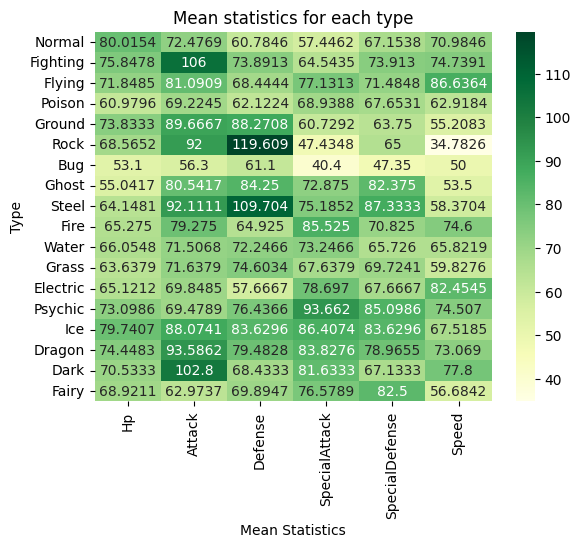

In [50]:
fig, ax = plt.subplots()

sns.heatmap(mean_values_df, annot=True, cmap='YlGn', fmt='g')
plt.title('Mean statistics for each type')
plt.xlabel('Mean Statistics')
plt.ylabel('Type')
plt.show()
fig.savefig('Images/Graphics/MeanStatsType.png', bbox_inches='tight')

In [51]:
mean_values_df.transpose()

for stat in STATS:
    fig = px.bar(mean_values_df[stat], title=f"Mean statistics for stat {stat}.",
                 color=COLOR_TYPES.keys(), color_discrete_map=COLOR_TYPES,
                 labels=dict(index="Type", value=f"Mean {stat}", color="Type color"))
    fig.update_layout(
    barmode="stack",
    title=dict(
                text=f"<br>Sum of mean stats by type",
                font=dict(
                    size=16
                )),
    title_x=0.5,
    xaxis={'categoryorder':'total descending'},
    yaxis_range=[0,max_mean_stat]
    )
    fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**Pokémon Type**

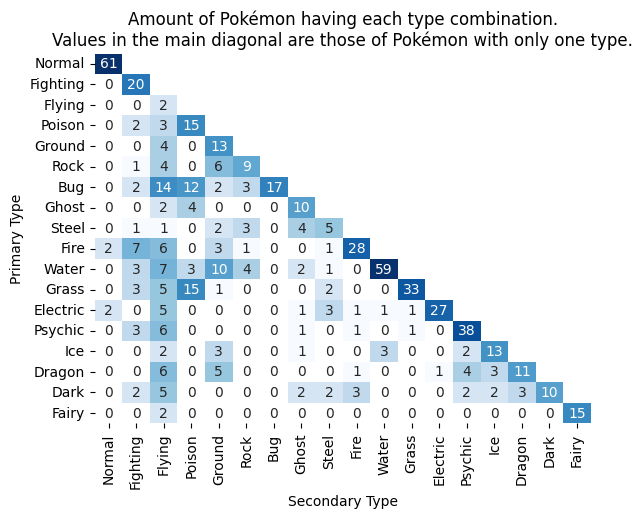

In [52]:
matrix = data.groupby(['Type1','Type2']).size().unstack(fill_value=0)
matrix = matrix[COLOR_TYPES.keys()].loc[COLOR_TYPES.keys()]

mask = np.triu(np.ones(matrix.shape, dtype=bool), k=1)

cmap = plt.colormaps.get_cmap('Blues').copy()
cmap.set_bad('white')
cmap.set_under('white')

plt.title("Amount of Pokémon having each type combination.\nValues in the main diagonal are those of Pokémon with only one type.")
sns.heatmap(matrix, annot=True, cmap=cmap, norm=LogNorm(), cbar=False, mask=mask)
plt.ylabel("Primary Type")
plt.xlabel("Secondary Type")
plt.show()

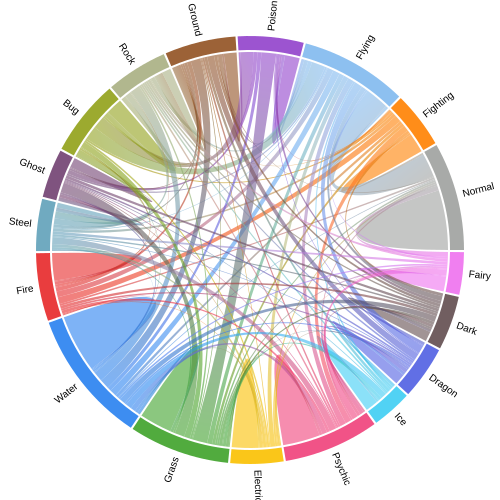

In [53]:
matrix = data.groupby(['Type1','Type2']).size().unstack(fill_value=0)
matrix = matrix[COLOR_TYPES.keys()].loc[COLOR_TYPES.keys()]
adjacency_matrix = matrix.copy()

for i in range(len(matrix)):
    for j in range(len(matrix)):
        if not j == i:
            adjacency_matrix.loc[matrix.keys()[i], matrix.keys()[j]] += matrix[matrix.keys()[i]][matrix.keys()[j]]


labels = list(COLOR_TYPES.keys())

fig = ocd.Chord(adjacency_matrix, labels)
fig.colormap = list(COLOR_TYPES.values())

fig.show()

<span style = "font-family: Verdana; font-size: 20px">

**Evolution Lines**

In [54]:
nwk = nx.DiGraph()
# print(nwk.is_directed())

for i in range(len(data)):
    nwk.add_node(data["Name"][i])   # Add Pokémon's name nodes
    if data["PreevoName"][i] != "No Preevolution":
        nwk.add_edge(data["PreevoName"][i], data["Name"][i])
# print(nwk)

pos = nx.spring_layout(nwk)
# print(pos)

# Egde formation
edge_x = []
edge_y = []
# print(nwk.edges())
for edge in nwk.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)
    
edge_trace = go.Scatter(
    x = edge_x, y = edge_y,
    line = dict(
        width=0.5, 
        color='#000000'
        ),
    hoverinfo = 'none',
    mode = 'lines'
)

node_x = []
node_y = []
for node in nwk.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    
node_trace = go.Scatter(
    x = node_x, y = node_y,
    mode = 'markers',
    hoverinfo = 'text',
    marker=dict(
        showscale = True,
        colorscale = 'PuBu',
        reversescale = True,
        color = [],
        size = 10,
        colorbar = dict(
            title = dict(
                text = 'Node Connections',
                side = 'right'
            ),
            xanchor = 'left',
        ),
        line_width = 1
    )
)

print(nwk)

# Color node
node_adjacencies = []
node_text = []
for node, adjacencies in enumerate(nwk.adjacency()):
    node_adjacencies.append(len(adjacencies[1]))
    node_text.append(f"Pokémon\'s name: {str(list(nwk)[node])}<br># of diffent evolutions: {str(len(adjacencies[1]))}")

node_trace.text = node_text
node_trace.marker.color = node_adjacencies

# Network
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title=dict(
                        text = '<br>Pokémon Evolution Network',
                        font = dict(size=16)
                    ),
                    showlegend = False,
                    hovermode = 'closest',
                    # marker = dict(
                    #     color = node_adjacencies
                    # ),
                    margin = dict(
                        b=20,l=5,r=5,t=40
                    ),
                    annotations=[
                        dict(
                            text = "Visualization Project",
                            showarrow = False,
                            xref = "paper",
                            yref = "paper",
                            x = 0.005,
                            y = -0.002
                        )
                    ],
                    xaxis = dict(
                        showgrid = False,
                        zeroline = False,
                        showticklabels = False
                    ),
                    yaxis = dict(
                        showgrid = False,
                        zeroline = False,
                        showticklabels = False
                    )
                )
            )
fig.update_layout(autosize = False,
                  width = 1000,
                  height = 1000)
fig.show()


DiGraph with 805 nodes and 413 edges


<span style = "font-family: Verdana; font-size: 20px">

**Abilities**

In [58]:
from tempfile import template


all_ability = []
for abi in ['Ability1', 'Ability2', 'HiddenAbility']:
    all_ability.extend(data[abi].unique().tolist())
    
all_ability = list(set(all_ability))
all_ability.remove('None')

print(f'Number of unique abilities: {len(all_ability)}')

all_ability_name_dict = {x: [] for x in all_ability}
for i in range(data.shape[0]):
    for abi_type in ['Ability1', 'Ability2', 'HiddenAbility']:
        x = data.at[i, abi_type]
        if not x == "None":
            all_ability_name_dict[x].append(data.at[i, 'Name'])
            
# print(all_ability_name_dict)

# Ability used by x Pokémon
amount_dict = {}
for  i in range(1, np.array([len(a) for a in all_ability_name_dict.values()]).max() + 1):
    amount_dict[i] = 0
    for key, value in all_ability_name_dict.items():
        if len(value) == i:
            amount_dict[i] += 1
            
# print(amount_dict)
for i in amount_dict.keys():
    print(i, [k for k, v in all_ability_name_dict.items() if len(v) == i]
)
    
df = pd.DataFrame(list(amount_dict.items()), columns=['Number of Pokémon', 'Number of Abilities'])

colorscale = 'Plasma'
normalized_heights = (df['Number of Abilities'] - df['Number of Abilities'].min()) / (df['Number of Abilities'].max() - df['Number of Abilities'].min()) # MinMaxScaling method

fig = go.Figure(data=[
        go.Bar(
            x = df['Number of Pokémon'],
            y = df['Number of Abilities'],
            marker = dict(
                color = normalized_heights,
                colorscale = colorscale,
                # showscale = True, # Interactive chart so unnessary
            )
        )
    ]
)

fig.update_layout(
    title = dict(
        text = f'<br>Number of Abilities used by certain number of Pokémon',
        font = dict(size=16)
    ),
    yaxis_title = dict(text='Number of Abilities'),
    xaxis_title = dict(text='Number of Pokémon'),
    title_x = 0.5,
    bargap = 0.1,
)

fig.show()
fig.write_image(f"Images/Graphics/AbilitiesPokemon.png")

Number of unique abilities: 196
1 ['Power Construct', 'Fairy Aura', 'Victory Star', 'Primordial Sea', 'Bad Dreams', 'Parental Bond', 'Slow Start', 'Wonder Guard', 'Imposter', 'Toxic Boost', 'Wind Rider', 'Aura Break', 'Flower Gift', 'Forecast', 'Desolate Land', 'Dark Aura', 'Stall', 'Air Lock', 'Color Change', 'Multitype', 'Sharpness', 'Fur Coat', 'Delta Stream']
2 ['Mummy', 'Turboblaze', 'Heatproof', 'Illusion', 'White Smoke', 'Aerilate', 'Stance Change', 'Zen Mode', 'Aroma Veil', 'Slush Rush', 'Iron Barbs', 'Sweet Veil', 'Defeatist', 'Grass Pelt', 'Honey Gather', 'Teravolt', 'Multiscale', 'Neutralizing Gas', 'Flare Boost', 'Normalize']
3 ['Refrigerate', 'Cheek Pouch', 'Immunity', 'Filter', 'Pure Power', 'Drizzle', 'Magma Armor', 'Mega Launcher', 'Truant', 'Gale Wings', 'Flower Veil', 'Poison Heal', 'Marvel Scale', 'Gooey', 'Strong Jaw', 'Arena Trap', 'Pixilate', 'Symbiosis', 'Bulletproof']
4 ['Motor Drive', 'Wonder Skin', 'Protean', 'Liquid Ooze', 'Download', 'Solid Rock']
5 ['Heavy 